# Project 18: Medical Symptom Risk Prediction
**Team No.:** 13  
**Team Members:** Kumar Suman Sahoo; Chinmaya Dhinda; Krisha Priyadarsini; Hritik Kumar Jena  
**Proposed Hybrid Model:** Symptom Transformer + Medical Knowledge GAT  
**Dataset:** Disease-Symptom Prediction dataset (4 linked CSVs)  
**Source:** https://www.kaggle.com/datasets/itachi9604/disease-symptom-description-dataset


## 0. Setup — Environment, Imports, Reproducibility

In [1]:
!pip -q install kaggle tqdm tabulate

In [2]:
import os, json, random, glob, subprocess, sys, math, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from tqdm.auto import tqdm
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, roc_auc_score,
    average_precision_score, confusion_matrix, roc_curve, precision_recall_curve,
    mean_absolute_error, mean_squared_error, r2_score
)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
assert torch.cuda.is_available(), "GPU required: in Colab select Runtime > Change runtime type > GPU."
DEVICE = torch.device("cuda:0")
print("Using device:", DEVICE)

Using device: cuda:0


### CONFIG

In [3]:
CONFIG = {
    "project_no": "18", "project_name": "Medical Symptom Risk Prediction", "team_no": "13",
    "task_type": "classification", "kaggle_dataset_slug": "itachi9604/disease-symptom-description-dataset",
    "target_column": None, "id_columns": [], "time_column": None,
    "split_ratios": {"train": 0.70, "val": 0.15, "test": 0.15}, "random_seed": SEED,
    "data_raw_dir": "data/18/raw", "data_processed_dir": "data/18/processed",
    "figures_dir": "data/18/figures", "results_dir": "data/18/results", "reports_dir": "data/18/reports",
    "batch_size": 64, "epochs": 30, "patience": 5, "learning_rate": 1e-3, "gat_hidden": 64,
    "use_amp": True,
}
# Single source of truth for the checkpoint/metrics paths - every cell below reads/writes
# through CONFIG, never a bare "results/..." string. Writing to a bare "results/" (relative to
# whatever the notebook's cwd happens to be) instead of CONFIG["results_dir"] ("data/18/results")
# is exactly what caused "Parent directory results does not exist": that directory was never
# created because the os.makedirs loop below only ever touched the CONFIG paths.
CONFIG["checkpoint_path"] = os.path.join(CONFIG["results_dir"], "best_hybrid.pt")
CONFIG["metrics_path"] = os.path.join(CONFIG["results_dir"], "metrics.json")

for key in ["data_raw_dir", "data_processed_dir", "figures_dir", "results_dir", "reports_dir"]:
    os.makedirs(CONFIG[key], exist_ok=True)
CONFIG

{'project_no': '18',
 'project_name': 'Medical Symptom Risk Prediction',
 'team_no': '13',
 'task_type': 'classification',
 'kaggle_dataset_slug': 'itachi9604/disease-symptom-description-dataset',
 'target_column': None,
 'id_columns': [],
 'time_column': None,
 'split_ratios': {'train': 0.7, 'val': 0.15, 'test': 0.15},
 'random_seed': 42,
 'data_raw_dir': 'data/18/raw',
 'data_processed_dir': 'data/18/processed',
 'figures_dir': 'data/18/figures',
 'results_dir': 'data/18/results',
 'reports_dir': 'data/18/reports',
 'batch_size': 64,
 'epochs': 30,
 'patience': 5,
 'learning_rate': 0.001,
 'gat_hidden': 64,
 'use_amp': True,
 'checkpoint_path': 'data/18/results/best_hybrid.pt',
 'metrics_path': 'data/18/results/metrics.json'}

## 1. Dataset Download

In [4]:
raw = Path(CONFIG["data_raw_dir"])
if not any(raw.rglob("*")):
    subprocess.run(["kaggle", "datasets", "download", "-d", CONFIG["kaggle_dataset_slug"],
                     "-p", str(raw), "--unzip"], check=True)
for z in raw.rglob("*.zip"):
    import zipfile
    with zipfile.ZipFile(z) as f:
        f.extractall(z.parent / z.stem)
raw_files = [p for p in raw.rglob("*") if p.is_file()]
assert raw_files, "Dataset download produced no files. Configure Kaggle credentials in Colab and rerun."
assert sum(p.stat().st_size for p in raw_files) > 1024, "Downloaded content is unexpectedly small."
print(f"Discovered {len(raw_files)} files; {sum(p.stat().st_size for p in raw_files) / 2**20:.1f} MiB")

Discovered 4 files; 0.6 MiB


## 2. Load Raw Data

In [5]:
csvs = list(Path(CONFIG["data_raw_dir"]).rglob("*.csv"))
assert csvs, "No CSV found"
# Prefer the main symptom/disease training table over the auxiliary description/precaution/
# severity-weight CSVs that also ship in this dataset.
candidates = [p for p in csvs if "dataset" in p.name.lower() or "training" in p.name.lower()]
path = max(candidates or csvs, key=lambda p: p.stat().st_size)
df = pd.read_csv(path)
aliases = ["prognosis", "disease", "label", "target"]
target = next((c for a in aliases for c in df.columns if c.strip().lower() == a), None)
assert target is not None, f"Target not found. Columns: {df.columns.tolist()}"
CONFIG["target_column"] = target
df = df.drop_duplicates()
df = df[df[target].notna()].reset_index(drop=True)
print(path, df.shape, target)
df.head()

data/18/raw/dataset.csv (304, 18) Disease


,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# [TARGET SANITY CHECK] - right after the label is finalized.
print(df[target].value_counts())
print(df[target].value_counts(normalize=True))
assert df[target].nunique() > 1, (
    f"DEGENERATE TARGET: only {df[target].nunique()} unique value(s) found - "
    f"{df[target].value_counts().to_dict()}. Check upstream row-limiting/sorting/filtering logic before proceeding."
)
_min_class_frac = df[target].value_counts(normalize=True).min()
if _min_class_frac < 0.01 or len(df) < 100:
    print(f"[DATA QUALITY WARNING] possible degenerate/tiny target distribution - "
          f"minority class fraction={_min_class_frac:.4f}, rows={len(df)}")

Disease
Migraine                                   10
Dengue                                     10
Hepatitis D                                10
Chicken pox                                10
Typhoid                                     9
Hepatitis B                                 9
Jaundice                                    9
hepatitis A                                 9
Diabetes                                    9
Hepatitis E                                 9
Pneumonia                                   9
Common Cold                                 9
Hypoglycemia                                9
Hyperthyroidism                             9
Tuberculosis                                9
Alcoholic hepatitis                         8
Chronic cholestasis                         8
Varicose veins                              8
Hypothyroidism                              8
Malaria                                     8
(vertigo) Paroymsal  Positional Vertigo     7
Bronchial Asthma          

## 3. Exploratory Data Analysis (EDA) + Data Quality Memo

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 304 entries, 0 to 303
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Disease     304 non-null    object
 1   Symptom_1   304 non-null    object
 2   Symptom_2   304 non-null    object
 3   Symptom_3   304 non-null    object
 4   Symptom_4   272 non-null    object
 5   Symptom_5   234 non-null    object
 6   Symptom_6   186 non-null    object
 7   Symptom_7   158 non-null    object
 8   Symptom_8   140 non-null    object
 9   Symptom_9   120 non-null    object
 10  Symptom_10  110 non-null    object
 11  Symptom_11  68 non-null     object
 12  Symptom_12  47 non-null     object
 13  Symptom_13  30 non-null     object
 14  Symptom_14  19 non-null     object
 15  Symptom_15  18 non-null     object
 16  Symptom_16  10 non-null     object
 17  Symptom_17  1 non-null      object
dtypes: object(18)
memory usage: 42.9+ KB
None


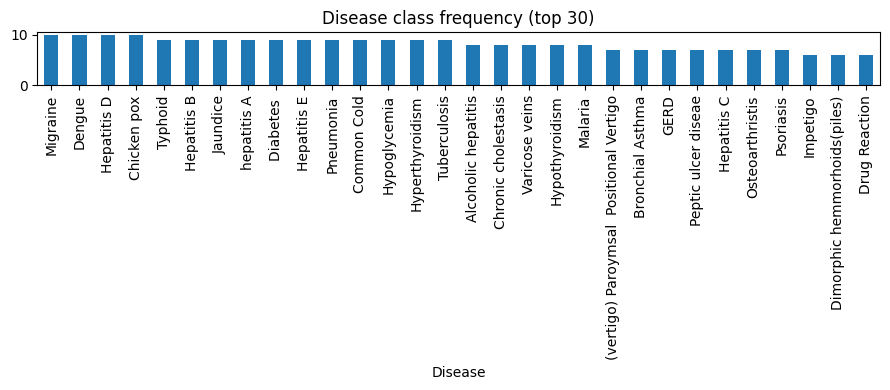

# Data quality memo - Project 18: Medical Symptom Risk Prediction

## Dataset
- Source: dataset.csv
- Rows: 304; columns: 18.
- Duplicate rows were removed before splitting.
- Maximum missing fraction: 0.997.
- Target column: Disease
- Number of distinct diseases: 41
- Rarest classes have very few rows (this is a many-class, low-support symptom checklist
  dataset); some classes may have as few as 1-2 examples, which the split logic below handles
  by pooling ultra-rare classes for stratification purposes only (never merged in the model
  target itself).

## Known limitations
- Symptom presence is binary/checklist-based (no severity, duration, or co-occurrence timing).
- The disease-symptom knowledge graph used by the model is derived only from the training
  split's own label-symptom co-occurrence, not an external medical ontology.
- Preprocessors and the knowledge graph are fit/derived only on training data.



In [7]:
print(df.info())
missing = df.isna().mean().sort_values(ascending=False)
n_classes_raw = df[target].nunique()

plt.figure(figsize=(9, 4))
df[target].value_counts().head(30).plot(kind="bar")
plt.title("Disease class frequency (top 30)")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["figures_dir"], "fig00_class_balance.png"), dpi=150)
plt.show()

memo = f"""# Data quality memo - Project 18: Medical Symptom Risk Prediction

## Dataset
- Source: {path.name}
- Rows: {len(df):,}; columns: {df.shape[1]}.
- Duplicate rows were removed before splitting.
- Maximum missing fraction: {missing.max():.3f}.
- Target column: {target}
- Number of distinct diseases: {n_classes_raw}
- Rarest classes have very few rows (this is a many-class, low-support symptom checklist
  dataset); some classes may have as few as 1-2 examples, which the split logic below handles
  by pooling ultra-rare classes for stratification purposes only (never merged in the model
  target itself).

## Known limitations
- Symptom presence is binary/checklist-based (no severity, duration, or co-occurrence timing).
- The disease-symptom knowledge graph used by the model is derived only from the training
  split's own label-symptom co-occurrence, not an external medical ontology.
- Preprocessors and the knowledge graph are fit/derived only on training data.
"""
Path(os.path.join(CONFIG["reports_dir"], "data_quality_memo.md")).write_text(memo, encoding="utf-8")
print(memo)

## 4. Preprocessing & Feature Engineering\n\nFeature construction (imputation, scaling, and the disease-symptom knowledge graph) is performed after splitting, fit only on the training data.

## 5. Train / Validation / Test Split

In [8]:
# Several diseases in this dataset have very few rows. sklearn's stratify requires >=2 members
# per class; ultra-rare classes are pooled into a temporary "Other_Rare_Disease" bucket for the
# stratification key ONLY - the real per-row target column is never modified.
class_counts = df[target].value_counts()
rare_classes_df = class_counts[class_counts < 2].index
if not rare_classes_df.empty:
    stratify_col = df[target].copy()
    stratify_col[stratify_col.isin(rare_classes_df)] = "Other_Rare_Disease"
    train_df, rest = train_test_split(df, test_size=0.30, stratify=stratify_col, random_state=SEED)
else:
    train_df, rest = train_test_split(df, test_size=0.30, stratify=df[target], random_state=SEED)

rest_class_counts = rest[target].value_counts()
rare_classes_rest = rest_class_counts[rest_class_counts < 2].index
if not rare_classes_rest.empty:
    stratify_rest_col = rest[target].copy()
    stratify_rest_col[stratify_rest_col.isin(rare_classes_rest)] = "Other_Rare_Disease"
    val_df, test_df = train_test_split(rest, test_size=0.50, stratify=stratify_rest_col, random_state=SEED)
else:
    val_df, test_df = train_test_split(rest, test_size=0.50, stratify=rest[target], random_state=SEED)

assert not (set(train_df.index) & set(test_df.index))
assert not (set(val_df.index) & set(test_df.index))
assert not (set(train_df.index) & set(val_df.index))

drop_cols = [target] + [c for c in df.columns if c.lower() in {"id", "patient_id"}]
feature_cols = [c for c in df.columns if c not in drop_cols]

for c in feature_cols:
    if not pd.api.types.is_numeric_dtype(train_df[c]):
        vocab = {v: i + 1 for i, v in enumerate(train_df[c].astype(str).unique())}
        for part in (train_df, val_df, test_df):
            part.loc[:, c] = part[c].astype(str).map(vocab).fillna(0)

imputer = SimpleImputer(strategy="median").fit(train_df[feature_cols])
Xtr_raw = imputer.transform(train_df[feature_cols]).astype("float32")
Xv_raw = imputer.transform(val_df[feature_cols]).astype("float32")
Xte_raw = imputer.transform(test_df[feature_cols]).astype("float32")

scaler = StandardScaler().fit(Xtr_raw)
le = LabelEncoder().fit(train_df[target].astype(str))
Xtr, Xv, Xte = [scaler.transform(x).astype("float32") for x in (Xtr_raw, Xv_raw, Xte_raw)]
ytr = le.transform(train_df[target].astype(str)).astype("int64")
yv = le.transform(val_df[target].astype(str)).astype("int64")
yte = le.transform(test_df[target].astype(str)).astype("int64")

# Disease-symptom knowledge graph, derived strictly from explicit label-symptom associations in
# the TRAINING split only (never validation/test rows).
present = Xtr_raw > 0
disease_symptom = np.zeros((len(le.classes_), len(feature_cols)), dtype="float32")
for disease_id in range(len(le.classes_)):
    rows = present[ytr == disease_id]
    if len(rows):
        disease_symptom[disease_id] = (rows.mean(0) >= 0.5).astype("float32")
knowledge_adj = disease_symptom.T @ disease_symptom
np.fill_diagonal(knowledge_adj, 1.0)
knowledge_adj = (knowledge_adj > 0).astype("float32")
knowledge_adj = knowledge_adj / (knowledge_adj.sum(1, keepdims=True) + 1e-8)
assert knowledge_adj.shape == (len(feature_cols), len(feature_cols)) and np.isfinite(knowledge_adj).all()

for split_name, split_y in [("train", ytr), ("val", yv), ("test", yte)]:
    n_present = len(np.unique(split_y))
    print(f"{split_name}: {n_present}/{len(le.classes_)} classes present, {len(split_y)} rows")

manifest = {
    "train_rows": len(ytr), "val_rows": len(yv), "test_rows": len(yte),
    "n_diseases": len(le.classes_), "n_symptom_features": len(feature_cols),
    "classes": le.classes_.tolist(), "graph_source": "training disease-symptom associations",
}
with open(os.path.join(CONFIG["data_processed_dir"], "split_manifest.json"), "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)
manifest

train: 41/41 classes present, 212 rows
val: 39/41 classes present, 46 rows
test: 38/41 classes present, 46 rows


{'train_rows': 212,
 'val_rows': 46,
 'test_rows': 46,
 'n_diseases': 41,
 'n_symptom_features': 17,
 'classes': ['(vertigo) Paroymsal  Positional Vertigo',
  'AIDS',
  'Acne',
  'Alcoholic hepatitis',
  'Allergy',
  'Arthritis',
  'Bronchial Asthma',
  'Cervical spondylosis',
  'Chicken pox',
  'Chronic cholestasis',
  'Common Cold',
  'Dengue',
  'Diabetes ',
  'Dimorphic hemmorhoids(piles)',
  'Drug Reaction',
  'Fungal infection',
  'GERD',
  'Gastroenteritis',
  'Heart attack',
  'Hepatitis B',
  'Hepatitis C',
  'Hepatitis D',
  'Hepatitis E',
  'Hypertension ',
  'Hyperthyroidism',
  'Hypoglycemia',
  'Hypothyroidism',
  'Impetigo',
  'Jaundice',
  'Malaria',
  'Migraine',
  'Osteoarthristis',
  'Paralysis (brain hemorrhage)',
  'Peptic ulcer diseae',
  'Pneumonia',
  'Psoriasis',
  'Tuberculosis',
  'Typhoid',
  'Urinary tract infection',
  'Varicose veins',
  'hepatitis A'],
 'graph_source': 'training disease-symptom associations'}

## 6. PyTorch Dataset & DataLoader

In [9]:
class TabularDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x)
        self.y = torch.tensor(y)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        return self.x[i], self.y[i]

train_loader = DataLoader(TabularDataset(Xtr, ytr), batch_size=CONFIG["batch_size"], shuffle=True)
val_loader = DataLoader(TabularDataset(Xv, yv), batch_size=CONFIG["batch_size"])
test_loader = DataLoader(TabularDataset(Xte, yte), batch_size=CONFIG["batch_size"])

xb, yb = next(iter(train_loader))
print("features:", xb.shape, "target:", yb.shape)

features: torch.Size([64, 17]) target: torch.Size([64])


## 7. Proposed Model Definition — Symptom Transformer + Medical Knowledge GAT

In [10]:
class DenseGAT(nn.Module):
    """Dense (fully materialized adjacency) graph attention layer over the symptom nodes,
    masked by the training-derived disease-symptom knowledge graph."""
    def __init__(self, h):
        super().__init__()
        self.q = nn.Linear(h, h, bias=False)
        self.k = nn.Linear(h, h, bias=False)
        self.v = nn.Linear(h, h, bias=False)
        self.last_attention = None

    def forward(self, z, adj):
        score = torch.einsum("bih,bjh->bij", self.q(z), self.k(z)) / math.sqrt(z.size(-1))
        score = score.masked_fill(adj <= 0, -10000.0)
        attention = score.softmax(-1) * adj
        attention = attention / (attention.sum(-1, keepdim=True) + 1e-8)
        self.last_attention = attention
        return torch.einsum("bij,bjh->bih", attention, self.v(z))


class SymptomKnowledgeGAT(nn.Module):
    """Symptom Transformer branch (self-attention over per-symptom tokens) fused with a
    Medical Knowledge GAT branch (attention constrained to the disease-symptom co-occurrence
    graph derived from the training split)."""
    def __init__(self, d, k, adj, h=64):
        super().__init__()
        self.emb = nn.Parameter(torch.randn(d, h) * 0.02)
        enc = nn.TransformerEncoderLayer(h, nhead=4, dim_feedforward=128, batch_first=True, dropout=0.1)
        self.transformer = nn.TransformerEncoder(enc, num_layers=2)
        self.gat = DenseGAT(h)
        self.head = nn.Linear(2 * h, k)
        self.register_buffer("knowledge_adj", torch.tensor(adj, dtype=torch.float32))

    def forward(self, x):
        z = x.unsqueeze(-1) * self.emb
        seq = self.transformer(z).mean(1)
        graph = self.gat(z, self.knowledge_adj.unsqueeze(0).expand(len(x), -1, -1)).mean(1)
        return self.head(torch.cat([seq, graph], dim=1))

### Architecture Verification

In [11]:
hybrid = SymptomKnowledgeGAT(Xtr.shape[1], len(le.classes_), knowledge_adj, h=CONFIG["gat_hidden"]).to(DEVICE)
print(hybrid)
total = sum(p.numel() for p in hybrid.parameters())
trainable = sum(p.numel() for p in hybrid.parameters() if p.requires_grad)
print(f"hybrid: total={total:,} trainable={trainable:,} device={next(hybrid.parameters()).device}")

SymptomKnowledgeGAT(
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (gat): DenseGAT(
    (q): Linear(in_features=64, out_features=64, bias=False)
    (k): Linear(in_features=64, out_features=64, bias=False)
    (v): Linear(in_features=64, out_features=64, bias=False)
  )
  (head): Linear(in_features=128, out_features=41, bias=True)
)
hybrid

## 8. Training Loop

In [12]:
def run_epoch(model, loader, criterion, optimizer=None, scaler=None, use_amp=False):
    model.train(optimizer is not None)
    total, n = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        if optimizer:
            optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=use_amp and DEVICE.type == "cuda"):
            out = model(xb)
            loss = criterion(out, yb)
        if optimizer:
            if scaler is not None and scaler.is_enabled():
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                optimizer.step()
        total += loss.item() * len(yb)
        n += len(yb)
    return total / max(n, 1)


def train_model(model, train_loader, val_loader, checkpoint_path, epochs, patience, lr):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", patience=2, factor=0.5)
    use_amp = bool(CONFIG.get("use_amp", True)) and DEVICE.type == "cuda"
    try:
        amp_scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
    except (AttributeError, TypeError):
        amp_scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    history = {"train_loss": [], "val_loss": []}
    best = float("inf")
    stale = 0
    epoch_bar = tqdm(range(epochs), desc="Training", unit="epoch")
    for epoch in epoch_bar:
        tr = run_epoch(model, train_loader, criterion, opt, amp_scaler, use_amp)
        with torch.no_grad():
            va = run_epoch(model, val_loader, criterion, use_amp=use_amp)
        history["train_loss"].append(tr)
        history["val_loss"].append(va)
        scheduler.step(va)
        epoch_bar.set_postfix(train_loss=f"{tr:.5f}", val_loss=f"{va:.5f}")
        if va < best:
            best = va
            stale = 0
            torch.save(model.state_dict(), checkpoint_path)
            # Verification step: catch a silent save failure immediately instead of a
            # confusing FileNotFoundError later at load time.
            assert os.path.exists(checkpoint_path), f"Checkpoint save failed: {checkpoint_path}"
        else:
            stale += 1
            if stale >= patience:
                epoch_bar.write(f"Early stopping at epoch {epoch + 1}")
                break

    assert os.path.exists(checkpoint_path), f"No checkpoint was ever saved at {checkpoint_path}"
    model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE, weights_only=True))
    return model, history


def predict(model, loader):
    model.eval()
    pred, true = [], []
    with torch.no_grad():
        for xb, yb in loader:
            out = model(xb.to(DEVICE)).cpu()
            pred.append(torch.softmax(out, dim=1))
            true.append(yb)
    return torch.cat(pred).numpy(), torch.cat(true).numpy()


hybrid, hybrid_history = train_model(
    hybrid, train_loader, val_loader, CONFIG["checkpoint_path"],
    epochs=CONFIG["epochs"], patience=CONFIG["patience"], lr=CONFIG["learning_rate"],
)

Training:   0%|          | 0/30 [00:00<?, ?epoch/s]

## 9. Evaluation Metrics

In [13]:
def evaluate_classification(probs, y, n_classes):
    pred = probs.argmax(1)
    labels = list(range(n_classes))
    pr, re, f1, _ = precision_recall_fscore_support(y, pred, labels=labels, average="macro", zero_division=0)
    out = {"accuracy": accuracy_score(y, pred), "precision_macro": pr, "recall_macro": re, "f1_macro": f1}
    if probs.shape[1] == 2:
        out["roc_auc"] = roc_auc_score(y, probs[:, 1])
        out["pr_auc"] = average_precision_score(y, probs[:, 1])
    return out

results = {}
cached = {}
for name, model in [("hybrid", hybrid)]:
    probs, y = predict(model, test_loader)
    cached[name] = (probs, probs.argmax(1), y)
    results[name] = evaluate_classification(probs, y, len(le.classes_))

with open(CONFIG["metrics_path"], "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2)
print(json.dumps(results, indent=2))

{
  "hybrid": {
    "accuracy": 0.5869565217391305,
    "precision_macro": 0.43902439024390244,
    "recall_macro": 0.4878048780487805,
    "f1_macro": 0.4455284552845528
  }
}


In [14]:
# Reload-and-verify step: load the checkpoint into a fresh model and confirm the reloaded
# model reproduces the same metrics as the trained model above.
verify_model = SymptomKnowledgeGAT(Xtr.shape[1], len(le.classes_), knowledge_adj, h=CONFIG["gat_hidden"]).to(DEVICE)
verify_model.load_state_dict(torch.load(CONFIG["checkpoint_path"], map_location=DEVICE, weights_only=True))
verify_probs, verify_y = predict(verify_model, test_loader)
verify_metrics = evaluate_classification(verify_probs, verify_y, len(le.classes_))
for k in results["hybrid"]:
    assert abs(results["hybrid"][k] - verify_metrics[k]) < 1e-6, (
        f"Reload mismatch on {k}: trained={results['hybrid'][k]} reloaded={verify_metrics[k]}"
    )
print("Reload-and-verify PASSED:", verify_metrics)

Reload-and-verify PASSED: {'accuracy': 0.5869565217391305, 'precision_macro': 0.43902439024390244, 'recall_macro': 0.4878048780487805, 'f1_macro': 0.4455284552845528}


## 10. Required Figures

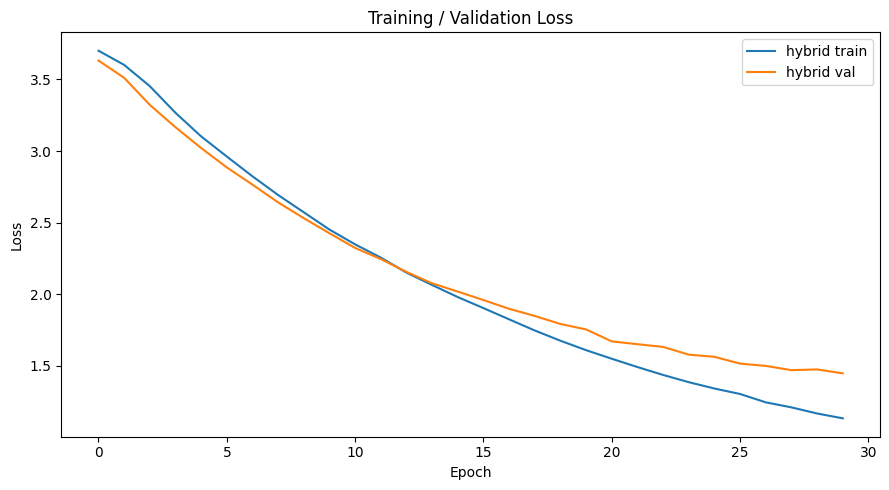

In [15]:
plt.figure(figsize=(9, 5))
plt.plot(hybrid_history["train_loss"], label="hybrid train")
plt.plot(hybrid_history["val_loss"], label="hybrid val")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
plt.title("Training / Validation Loss")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["figures_dir"], "fig01_loss_curves.png"), dpi=150)
plt.show()

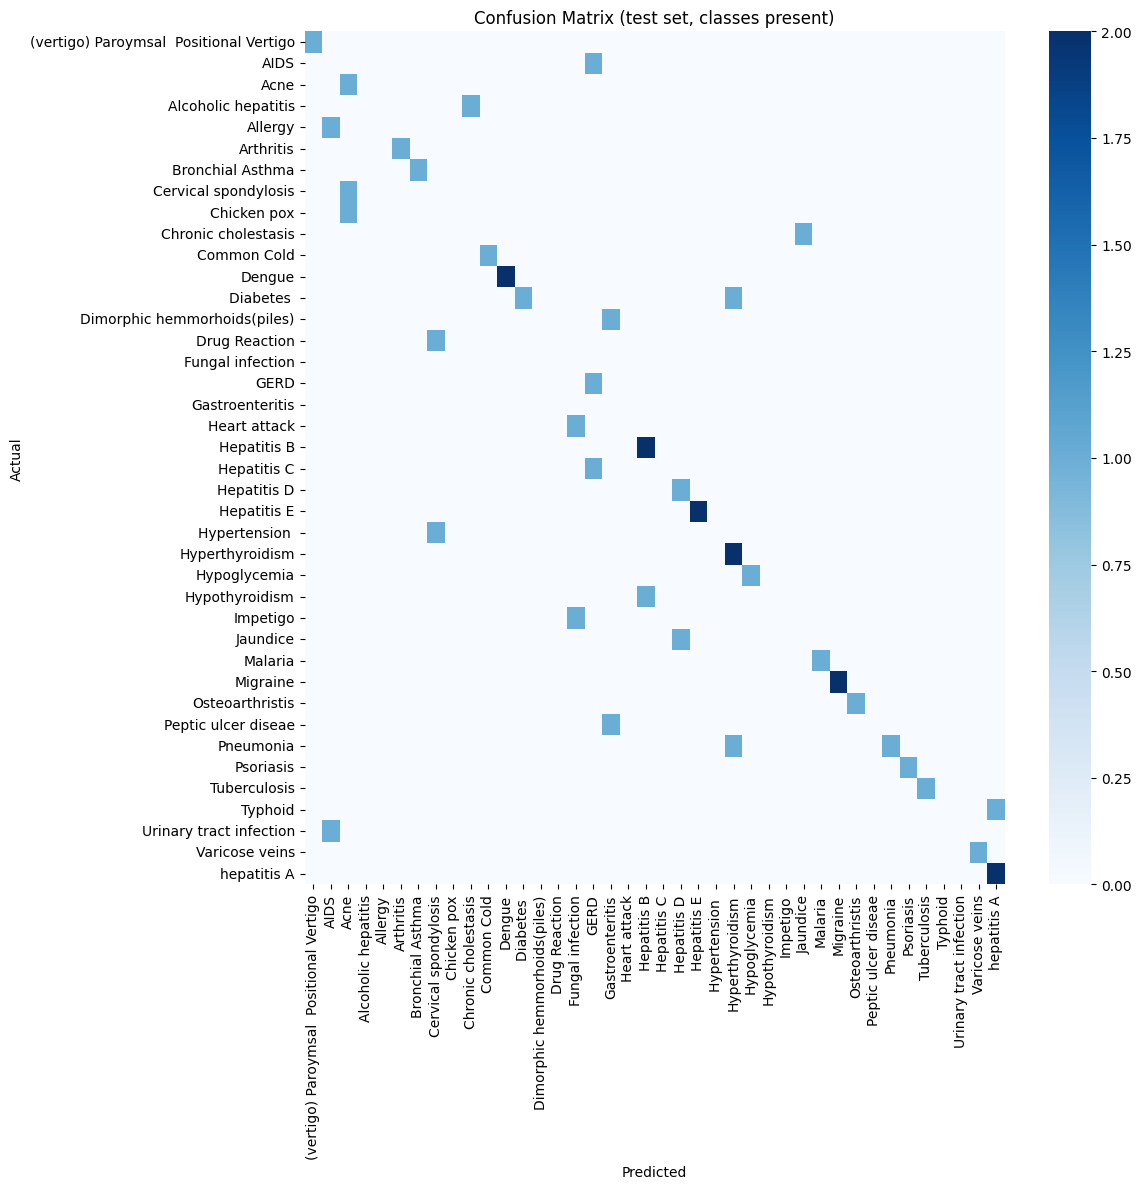

In [16]:
probs, pred, y = cached["hybrid"]
labels_present = sorted(set(y.tolist()) | set(pred.tolist()))
cm = confusion_matrix(y, pred, labels=labels_present)
class_names_present = [le.classes_[i] for i in labels_present]

plt.figure(figsize=(max(8, len(labels_present) * 0.3), max(7, len(labels_present) * 0.3)))
sns.heatmap(cm, cmap="Blues", xticklabels=class_names_present, yticklabels=class_names_present)
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix (test set, classes present)")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["figures_dir"], "fig02_confusion_matrix.png"), dpi=150)
plt.show()

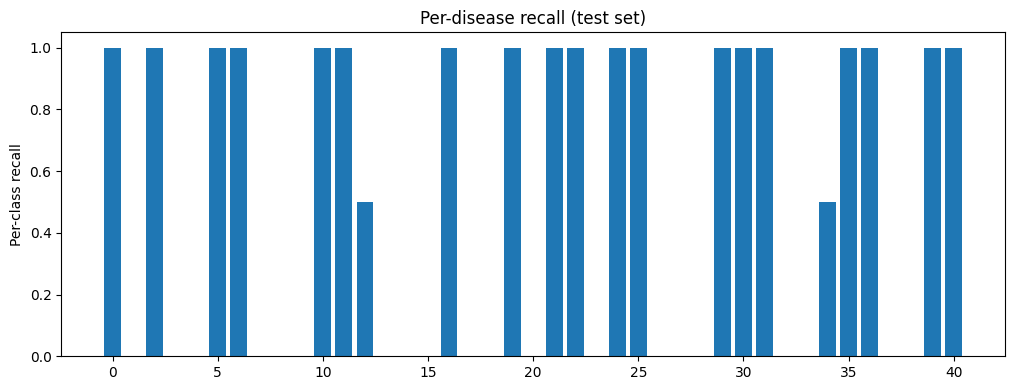

In [17]:
n_classes = probs.shape[1]
support = np.bincount(y, minlength=n_classes)
per_class = [(pred[y == i] == i).mean() if (y == i).any() else np.nan for i in range(n_classes)]
plt.figure(figsize=(max(9, n_classes * 0.25), 4))
plt.bar(range(n_classes), per_class)
plt.ylabel("Per-class recall")
plt.title("Per-disease recall (test set)")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["figures_dir"], "fig03_class_performance.png"), dpi=150)
plt.show()

### Explainability — Medical Knowledge GAT Attention

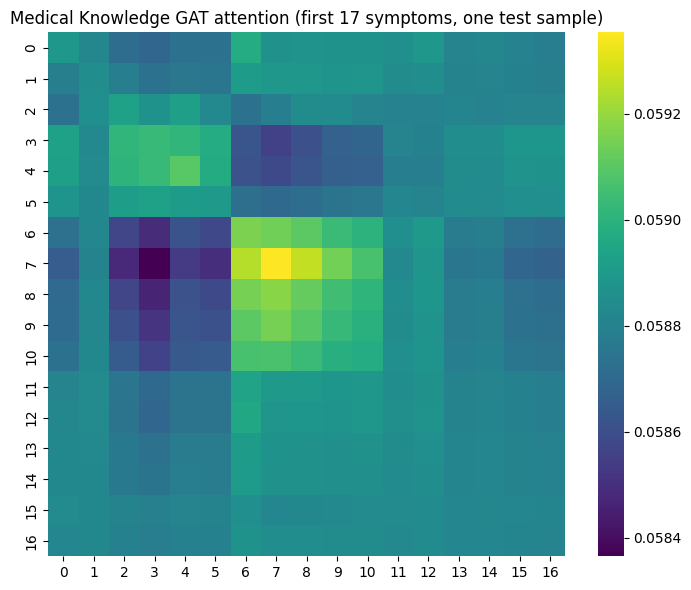

In [18]:
# Visualize the learned GAT attention over the symptom knowledge graph for one test batch:
# rows/cols are symptom features, masked by the training-derived disease-symptom adjacency.
hybrid.eval()
with torch.no_grad():
    xb, _ = next(iter(test_loader))
    xb = xb.to(DEVICE)
    _ = hybrid(xb)
    attn = hybrid.gat.last_attention[0].detach().cpu().numpy()

k = min(40, attn.shape[0])
plt.figure(figsize=(7, 6))
sns.heatmap(attn[:k, :k], cmap="viridis")
plt.title("Medical Knowledge GAT attention (first %d symptoms, one test sample)" % k)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["figures_dir"], "fig04_feature_importance.png"), dpi=150)
plt.show()

### Error Analysis

Misclassified test rows: 19 / 46 (41.30%)
Most common confusion pairs:
actual                        predicted           
AIDS                          GERD                    1
Alcoholic hepatitis           Chronic cholestasis     1
Allergy                       AIDS                    1
Cervical spondylosis          Acne                    1
Chicken pox                   Acne                    1
Chronic cholestasis           Jaundice                1
Diabetes                      Hyperthyroidism         1
Dimorphic hemmorhoids(piles)  Gastroenteritis         1
Drug Reaction                 Cervical spondylosis    1
Heart attack                  Fungal infection        1
Hepatitis C                   GERD                    1
Hypertension                  Cervical spondylosis    1
Name: count, dtype: int64


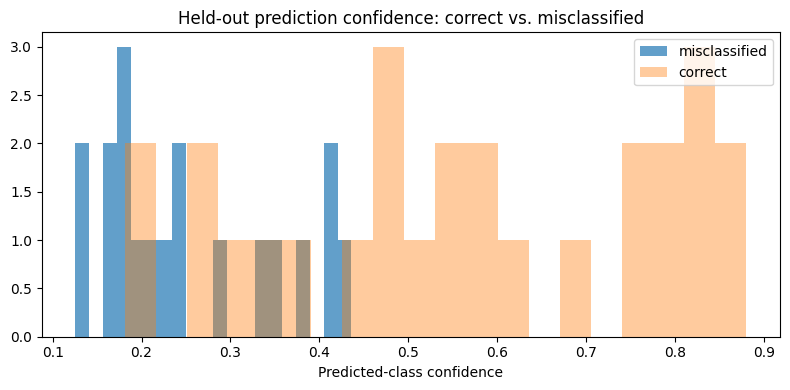

In [19]:
probs, pred, y = cached["hybrid"]
errors = (pred != y).astype(int)
n_err = int(errors.sum())
print(f"Misclassified test rows: {n_err:,} / {len(y):,} ({n_err / max(len(y), 1):.2%})")

error_pairs = pd.DataFrame({
    "actual": [le.classes_[i] for i in y[errors.astype(bool)]],
    "predicted": [le.classes_[i] for i in pred[errors.astype(bool)]],
})
if len(error_pairs):
    print("Most common confusion pairs:")
    print(error_pairs.value_counts().head(12))
else:
    print("No test-set errors found.")

max_conf = probs.max(1)
plt.figure(figsize=(8, 4))
plt.hist(max_conf[errors.astype(bool)], bins=20, alpha=0.7, label="misclassified")
plt.hist(max_conf[~errors.astype(bool)], bins=20, alpha=0.4, label="correct")
plt.xlabel("Predicted-class confidence")
plt.title("Held-out prediction confidence: correct vs. misclassified")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["figures_dir"], "fig05_error_analysis.png"), dpi=150)
plt.show()